# Annotated Examples EDA

Analysis of tejo9855's annotations only. Setting (150 instances, 1–3 scale) and agency (101 instances, 1–5 scale). Topics with fewer than `MIN_TOPIC_N` instances are excluded from rating-by-topic plots.

In [11]:
import csv
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

MIN_TOPIC_N          = 5     # minimum instances per topic to include in rating plots
EXCLUDE_UNKNOWN_TOPIC = False  # drop instances whose topic_classification == 'Unknown'

In [12]:
import os
BASE = os.path.join(os.path.dirname(os.path.abspath('.')), 'teagan_tasks') \
       if os.path.basename(os.getcwd()) != 'annotation_analysis' else '..'

DATA_CSV = f'{BASE}/setting_annotation_task/data/dolma_final_sample_s42_n1250_t0.5_llm_summary_safeid_with_spans.csv'

TASK_CONFIGS = {
    'setting': {
        'results_dir': f'{BASE}/setting_annotation_task/annotation_output/results',
        'dims': ['setting_concreteness', 'setting_temporal_grounding',
                 'setting_spatial_grounding', 'setting_sensory'],
        'scale': (1, 3),
        'color': '#4caf50',
    },
    'agency': {
        'results_dir': f'{BASE}/agency_annotation_task/agency_annotations/annotation_output/results',
        'dims': ['agency_focalization', 'agency_emotion', 'agency_cognition',
                 'agency_change_of_state', 'agency_conflict'],
        'scale': (1, 5),
        'color': '#f4a432',
    },
}

ANNOTATOR = 'tejo9855'

In [13]:
def load_likert(results_dir, annotator):
    path = f'{results_dir}/{annotator}/user_state.json'
    import json
    with open(path) as f:
        state = json.load(f)
    rows = []
    for inst_id, labels in state['instance_id_to_label_to_value'].items():
        row = {'safe_instance_id': inst_id}
        for entry in labels:
            row[entry[0]['schema']] = int(entry[0]['name'])
        rows.append(row)
    return pd.DataFrame(rows)

setting_df = load_likert(TASK_CONFIGS['setting']['results_dir'], ANNOTATOR)
agency_df  = load_likert(TASK_CONFIGS['agency']['results_dir'],  ANNOTATOR)

# metadata
csv.field_size_limit(10**7)
with open(DATA_CSV) as f:
    meta = pd.DataFrame([{
        'safe_instance_id':      r['safe_instance_id'],
        'topic_classification':  r['topic_classification'],
        'folder':                r['folder'],
        'source':                r['source'],
        'is_noise':              r['is_noise'] == 'True',
        'narrative_label':       r['narrative_label'],
    } for r in csv.DictReader(f)])

# Replace Unknown topics with the data source so every instance has a meaningful label
unknown_mask = meta['topic_classification'] == 'Unknown'
meta.loc[unknown_mask, 'topic_classification'] = (
    'Shard: ' + meta.loc[unknown_mask, 'source'].str.title()
)

setting_df = setting_df.merge(meta, on='safe_instance_id', how='left')
agency_df  = agency_df.merge(meta,  on='safe_instance_id', how='left')

if EXCLUDE_UNKNOWN_TOPIC:
    setting_df = setting_df[setting_df['topic_classification'] != 'Unknown']
    agency_df  = agency_df[agency_df['topic_classification']  != 'Unknown']

print(f'Setting:  {len(setting_df)} annotated instances')
print(f'Agency:   {len(agency_df)} annotated instances')
print(f'Overlap:  {len(set(setting_df.safe_instance_id) & set(agency_df.safe_instance_id))} instances in both')
print()
print('Topic distribution (setting):')
print(setting_df['topic_classification'].value_counts().to_string())

Setting:  400 annotated instances
Agency:   400 annotated instances
Overlap:  400 instances in both

Topic distribution (setting):
topic_classification
Shard: Reddit         35
Sports & Fitness      29
Shard: Gutenberg      21
Home & Hobbies        21
Crime & Law           20
Social Life           19
Politics              19
Literature            18
Finance & Business    18
Health                17
Travel                16
History               16
Entertainment         15
Food & Dining         13
Science & Tech.       13
Art & Design          13
Software              12
Education & Jobs      11
Religion              11
Games                 10
Transportation        10
Hardware               8
Shard: Wikipedia       8
Industrial             8
Fashion & Beauty       7
Software Dev.          7
Shard: Megawika        4
Adult                  1


## 1. Annotation counts

In [14]:
summary = {
    'Setting (tejo9855)':  len(setting_df),
    'Agency (tejo9855)':   len(agency_df),
    'Overlap (both tasks)': len(set(setting_df.safe_instance_id) & set(agency_df.safe_instance_id)),
}
pd.DataFrame.from_dict(summary, orient='index', columns=['Count'])

,Count
Setting (tejo9855),400
Agency (tejo9855),400
Overlap (both tasks),400


## 2. Topic distribution of annotated instances

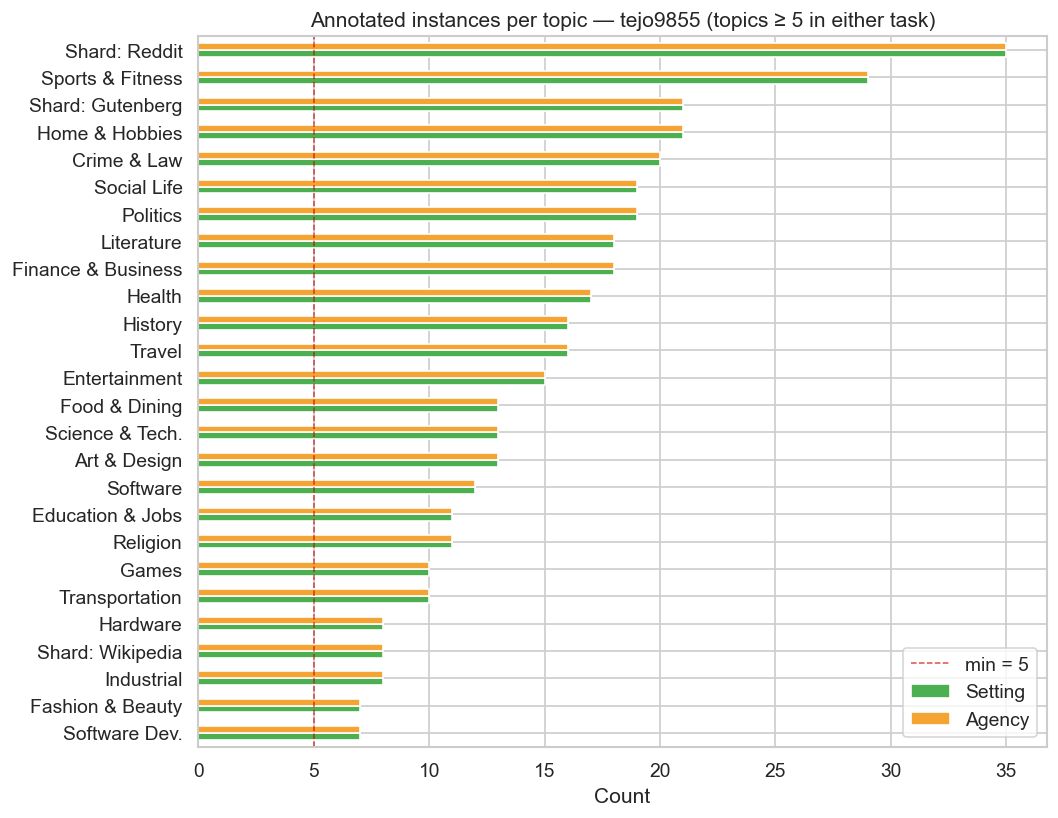

                      Setting  Agency
topic_classification                 
Shard: Reddit              35      35
Sports & Fitness           29      29
Shard: Gutenberg           21      21
Home & Hobbies             21      21
Crime & Law                20      20
Social Life                19      19
Politics                   19      19
Literature                 18      18
Finance & Business         18      18
Health                     17      17
Travel                     16      16
History                    16      16
Entertainment              15      15
Food & Dining              13      13
Science & Tech.            13      13
Art & Design               13      13
Software                   12      12
Education & Jobs           11      11
Religion                   11      11
Games                      10      10
Transportation             10      10
Hardware                    8       8
Shard: Wikipedia            8       8
Industrial                  8       8
Fashion & Be

In [15]:
setting_tc = setting_df['topic_classification'].value_counts().rename('Setting')
agency_tc  = agency_df['topic_classification'].value_counts().rename('Agency')
topic_counts = pd.concat([setting_tc, agency_tc], axis=1).fillna(0).astype(int)
topic_counts['_max'] = topic_counts.max(axis=1)
topic_eligible = topic_counts[topic_counts['_max'] >= MIN_TOPIC_N].drop(columns='_max')
topic_eligible = topic_eligible.sort_values('Setting', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
topic_eligible.plot(kind='barh', ax=ax,
    color=[TASK_CONFIGS['setting']['color'], TASK_CONFIGS['agency']['color']],
    edgecolor='white')
ax.axvline(MIN_TOPIC_N, color='#c00', linestyle='--', linewidth=0.9, alpha=0.7,
           label=f'min = {MIN_TOPIC_N}')
ax.set_title(f'Annotated instances per topic — {ANNOTATOR} (topics ≥ {MIN_TOPIC_N} in either task)')
ax.set_xlabel('Count')
ax.set_ylabel('')
ax.legend()
plt.tight_layout()
plt.show()

print(topic_eligible.sort_values('Setting', ascending=False).to_string())

## 3. Setting ratings by topic

Mean rating per dimension for topics with ≥ `MIN_TOPIC_N` setting annotations. Scale 1–3.

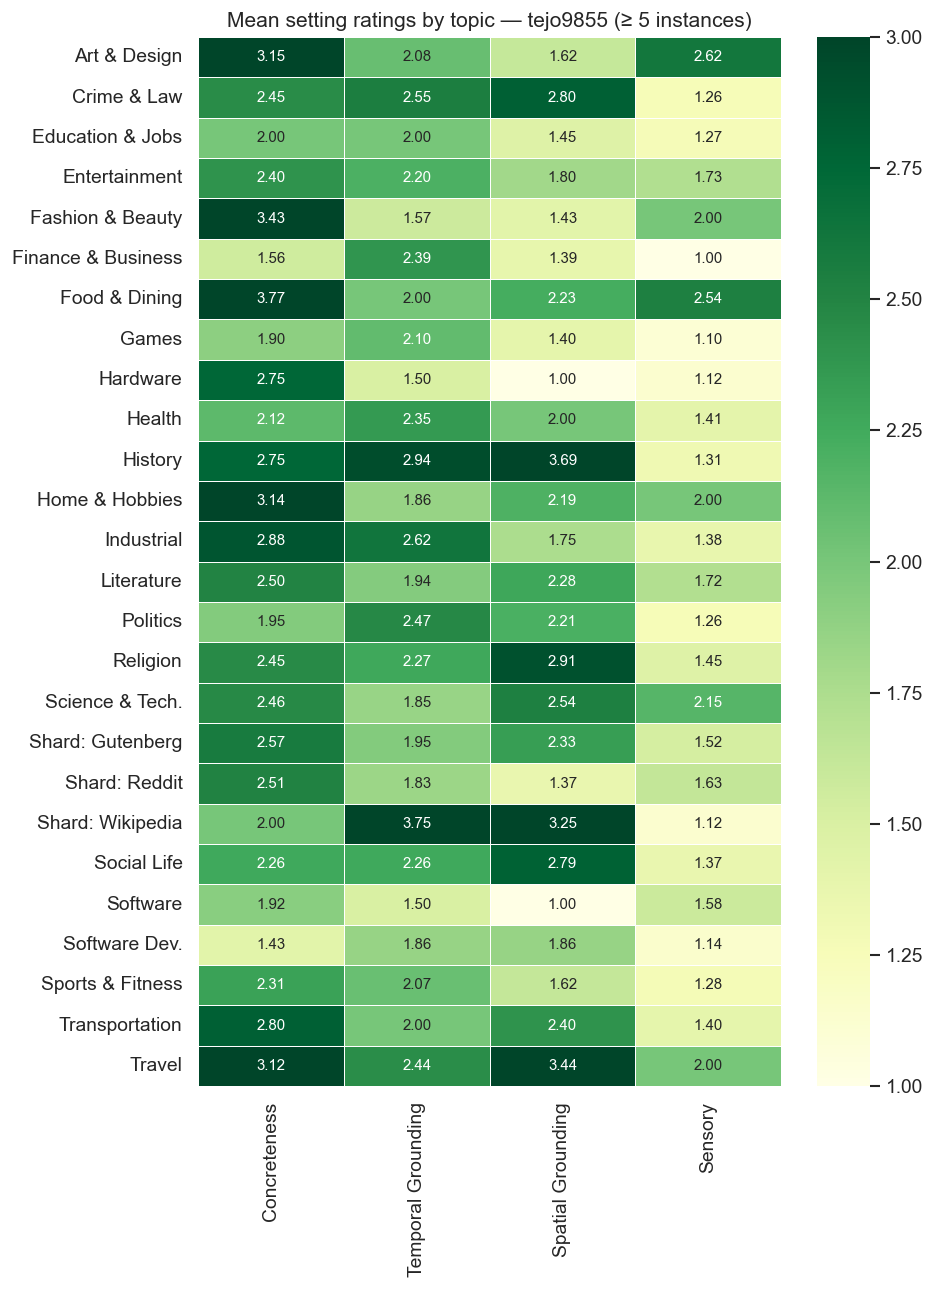

In [16]:
SETTING_DIMS = TASK_CONFIGS['setting']['dims']
setting_short = {d: d.replace('setting_', '').replace('_', ' ').title() for d in SETTING_DIMS}

st_eligible = setting_df['topic_classification'].value_counts()
st_eligible = st_eligible[st_eligible >= MIN_TOPIC_N].index

st_by_topic = (setting_df[setting_df['topic_classification'].isin(st_eligible)]
    .groupby('topic_classification')[SETTING_DIMS].mean()
    .rename(columns=setting_short)
    .sort_index())

fig, ax = plt.subplots(figsize=(8, max(5, len(st_by_topic) * 0.42)))
sns.heatmap(st_by_topic, annot=True, fmt='.2f', cmap='YlGn',
            vmin=1, vmax=3, linewidths=0.3, ax=ax, annot_kws={'size': 9})
ax.set_title(f'Mean setting ratings by topic — {ANNOTATOR} (≥ {MIN_TOPIC_N} instances)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 4. Agency ratings by topic

Mean rating per dimension for topics with ≥ `MIN_TOPIC_N` agency annotations. Scale 1–5.

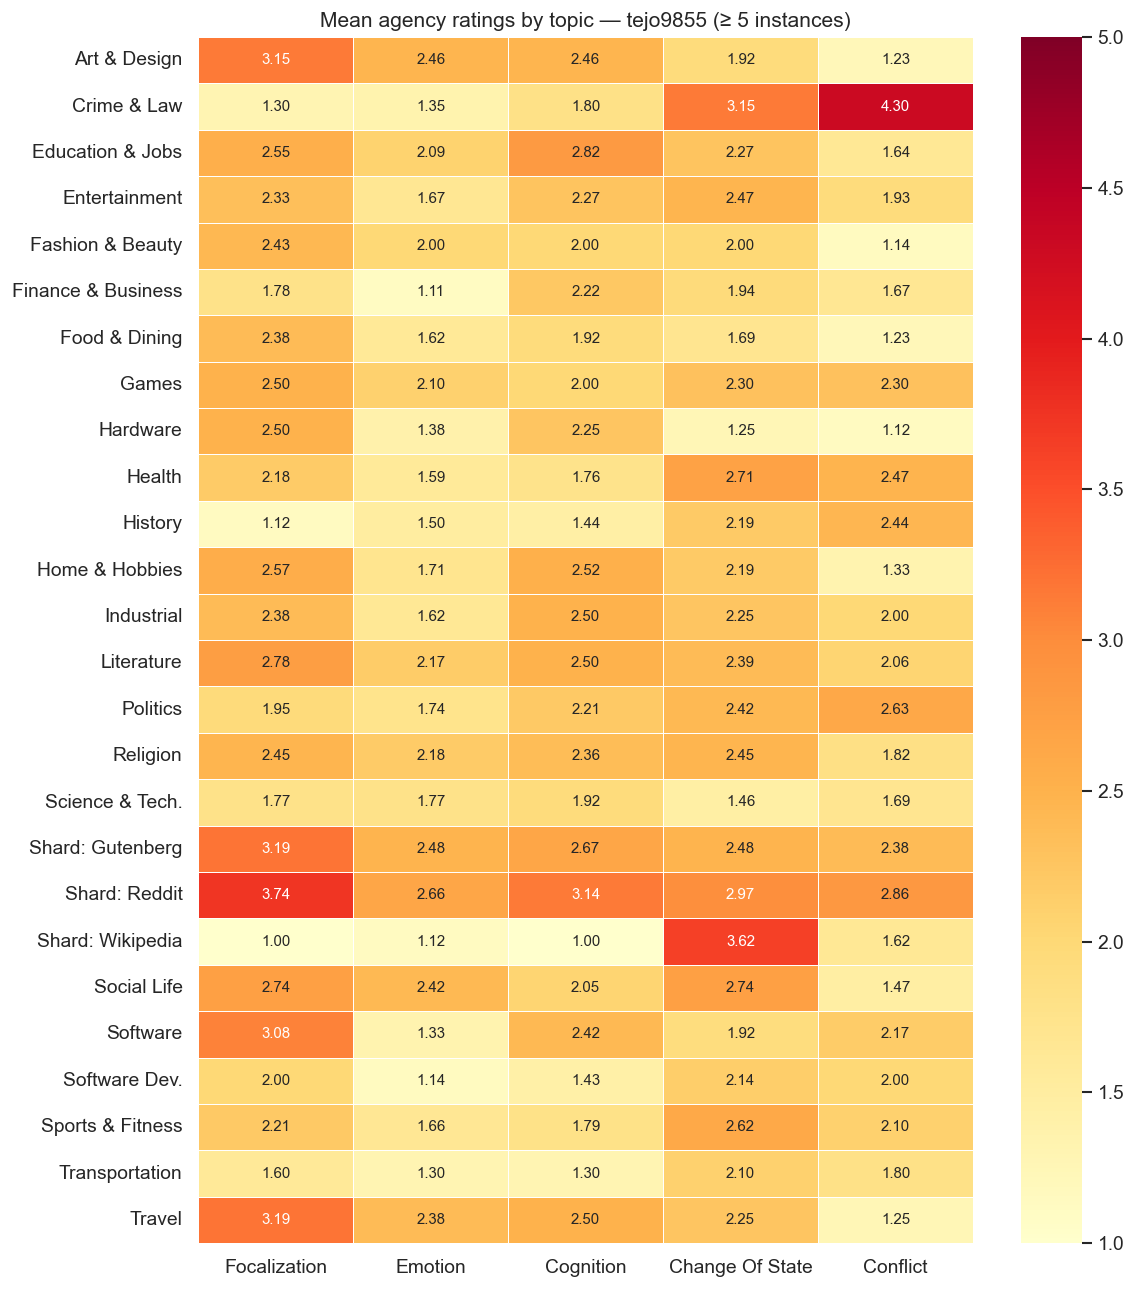

In [17]:
AGENCY_DIMS = TASK_CONFIGS['agency']['dims']
agency_short = {d: d.replace('agency_', '').replace('_', ' ').title() for d in AGENCY_DIMS}

ag_eligible = agency_df['topic_classification'].value_counts()
ag_eligible = ag_eligible[ag_eligible >= MIN_TOPIC_N].index

ag_by_topic = (agency_df[agency_df['topic_classification'].isin(ag_eligible)]
    .groupby('topic_classification')[AGENCY_DIMS].mean()
    .rename(columns=agency_short)
    .sort_index())

fig, ax = plt.subplots(figsize=(10, max(5, len(ag_by_topic) * 0.42)))
sns.heatmap(ag_by_topic, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=1, vmax=5, linewidths=0.3, ax=ax, annot_kws={'size': 9})
ax.set_title(f'Mean agency ratings by topic — {ANNOTATOR} (≥ {MIN_TOPIC_N} instances)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 6. Cross-task correlation: Setting × Agency

Spearman correlations across the 250 instances annotated in both tasks.

## 5. Annotation label distributions

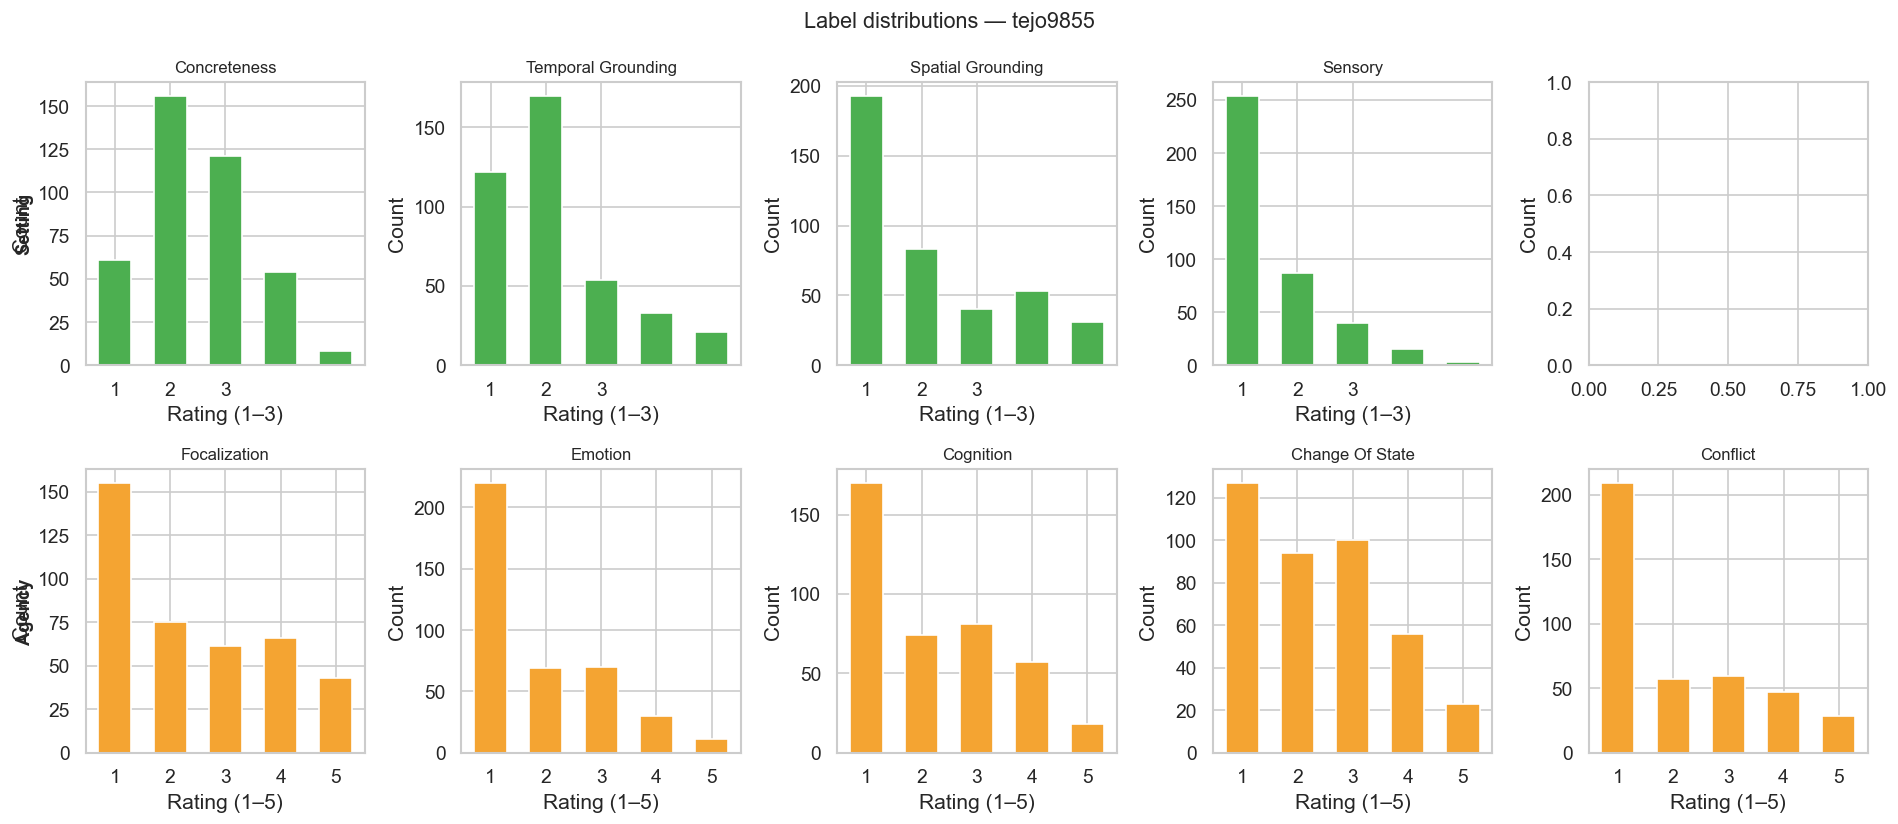

In [18]:
SETTING_DIMS = TASK_CONFIGS['setting']['dims']
setting_short = {d: d.replace('setting_', '').replace('_', ' ').title() for d in SETTING_DIMS}

AGENCY_DIMS = TASK_CONFIGS['agency']['dims']
agency_short = {d: d.replace('agency_', '').replace('_', ' ').title() for d in AGENCY_DIMS}

fig, axes = plt.subplots(2, max(len(SETTING_DIMS), len(AGENCY_DIMS)),
                         figsize=(4 * len(SETTING_DIMS), 7))

for ax, dim in zip(axes[0], SETTING_DIMS):
    counts = setting_df[dim].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=TASK_CONFIGS['setting']['color'],
           edgecolor='white', width=0.6)
    ax.set_title(setting_short[dim], fontsize=10)
    ax.set_xlabel('Rating (1–3)')
    ax.set_xticks([1, 2, 3])

for ax, dim in zip(axes[1], AGENCY_DIMS):
    counts = agency_df[dim].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=TASK_CONFIGS['agency']['color'],
           edgecolor='white', width=0.6)
    ax.set_title(agency_short[dim], fontsize=10)
    ax.set_xlabel('Rating (1–5)')
    ax.set_xticks([1, 2, 3, 4, 5])

for ax in axes.flat:
    ax.set_ylabel('Count')

# hide unused axes in row 1 if agency has fewer dims than setting
for ax in axes[1][len(AGENCY_DIMS):]:
    ax.set_visible(False)

axes[0][0].annotate('Setting', xy=(-0.25, 0.5), xycoords='axes fraction',
                    fontsize=11, fontweight='bold', va='center', rotation=90)
axes[1][0].annotate('Agency', xy=(-0.25, 0.5), xycoords='axes fraction',
                    fontsize=11, fontweight='bold', va='center', rotation=90)

plt.suptitle(f'Label distributions — {ANNOTATOR}', fontsize=13)
plt.tight_layout()
plt.show()

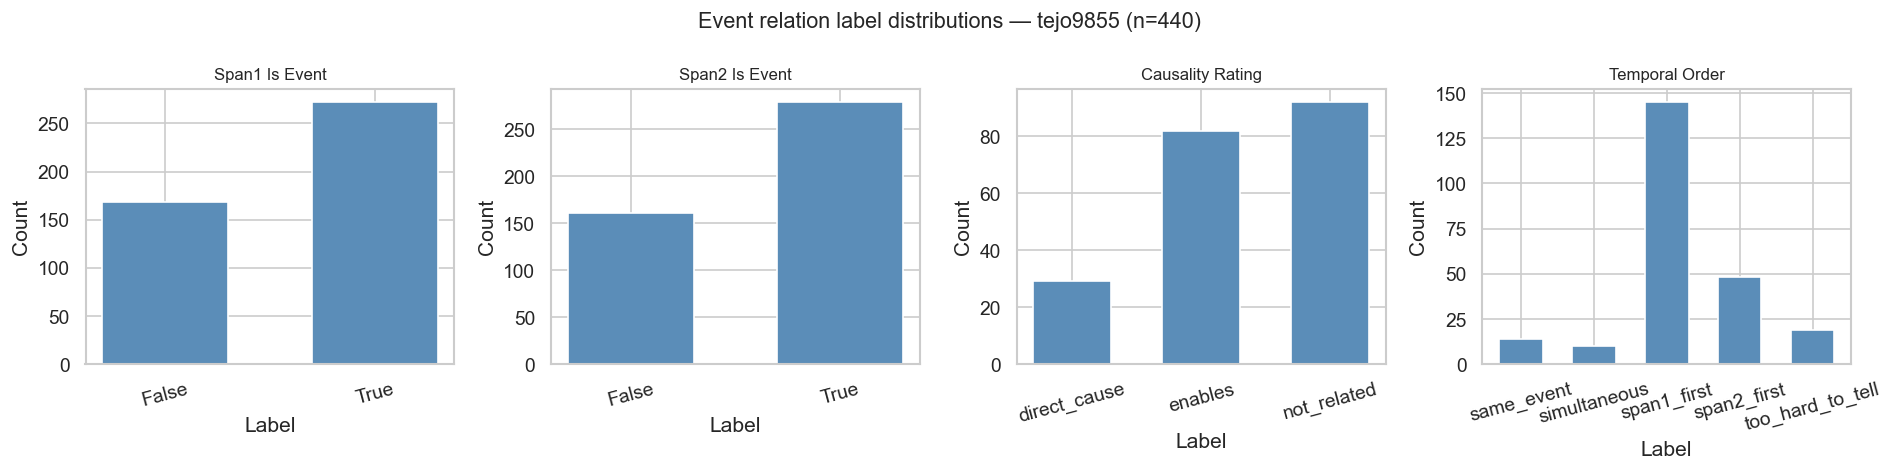

In [19]:
event_df_raw = pd.read_parquet('event_relation_annotations.parquet')
EVENT_COLS = [c for c in event_df_raw.columns if c.endswith(f'_{ANNOTATOR}')]
event_short = {c: c.replace(f'_{ANNOTATOR}', '').replace('_', ' ').title() for c in EVENT_COLS}

fig, axes = plt.subplots(1, len(EVENT_COLS), figsize=(4 * len(EVENT_COLS), 4))

for ax, col in zip(axes, EVENT_COLS):
    counts = event_df_raw[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color='#5b8db8', edgecolor='white', width=0.6)
    ax.set_title(event_short[col], fontsize=10)
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle(f'Event relation label distributions — {ANNOTATOR} (n={len(event_df_raw)})', fontsize=13)
plt.tight_layout()
plt.show()

Cross-task instances: 350
NaN counts per dim:
setting_concreteness          0
setting_temporal_grounding    0
setting_spatial_grounding     0
setting_sensory               1
agency_focalization           0
agency_emotion                1
agency_cognition              0
agency_change_of_state        0
agency_conflict               0


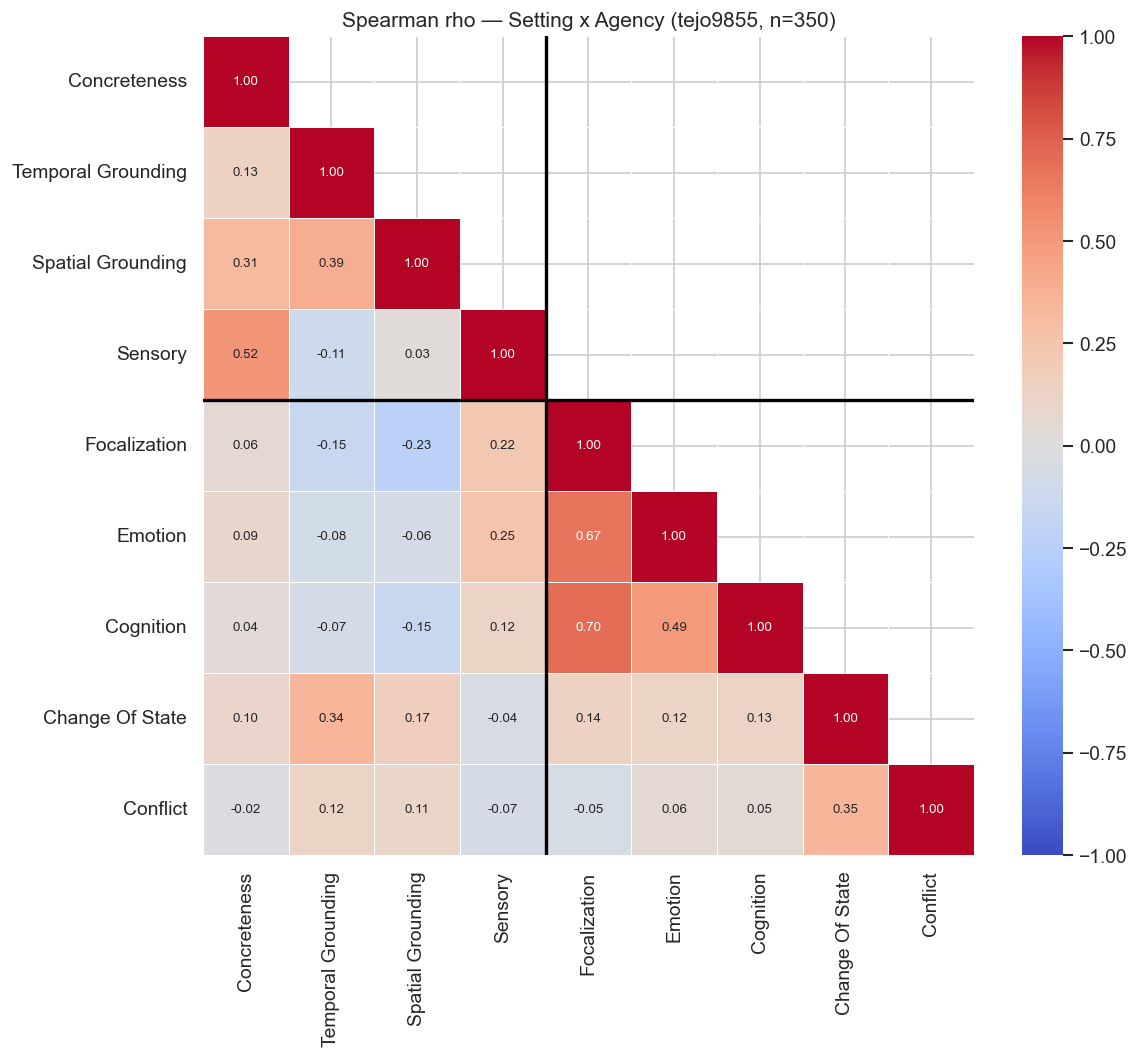

In [10]:
ALL_DIMS = SETTING_DIMS + AGENCY_DIMS
SHORT = {**setting_short, **agency_short}

cross_df = (setting_df[["safe_instance_id"] + SETTING_DIMS]
    .merge(agency_df[["safe_instance_id"] + AGENCY_DIMS], on="safe_instance_id", how="inner"))
print(f"Cross-task instances: {len(cross_df)}")
print("NaN counts per dim:")
print(cross_df[ALL_DIMS].isna().sum().to_string())

# Full Spearman correlation matrix — nan_policy="omit" drops pairs where either value is NaN
corr_vals = pd.DataFrame(index=ALL_DIMS, columns=ALL_DIMS, dtype=float)
pval_vals = pd.DataFrame(index=ALL_DIMS, columns=ALL_DIMS, dtype=float)
for d1 in ALL_DIMS:
    for d2 in ALL_DIMS:
        r, p = spearmanr(cross_df[d1], cross_df[d2], nan_policy="omit")
        corr_vals.loc[d1, d2] = r
        pval_vals.loc[d1, d2] = p

corr_display = corr_vals.rename(index=SHORT, columns=SHORT)

fig, ax = plt.subplots(figsize=(10, 9))
import numpy as np
mask = np.triu(np.ones_like(corr_display, dtype=bool), k=1)
sns.heatmap(corr_display.astype(float), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax,
            annot_kws={"size": 8}, mask=mask)
n_setting = len(SETTING_DIMS)
ax.axhline(n_setting, color="black", linewidth=2)
ax.axvline(n_setting, color="black", linewidth=2)
ax.set_title(f"Spearman rho — Setting x Agency ({ANNOTATOR}, n={len(cross_df)})")
plt.tight_layout()
plt.show()

In [9]:
# Top cross-task correlations (setting dim vs agency dim)
cross_corrs = []
for sd in SETTING_DIMS:
    for ad in AGENCY_DIMS:
        r = corr_vals.loc[sd, ad]
        p = pval_vals.loc[sd, ad]
        cross_corrs.append({'setting': SHORT[sd], 'agency': SHORT[ad], 'rho': r, 'p': p})
cross_corr_df = (pd.DataFrame(cross_corrs)
    .sort_values('rho', key=abs, ascending=False)
    .reset_index(drop=True))
cross_corr_df['rho'] = cross_corr_df['rho'].round(3)
cross_corr_df['p']   = cross_corr_df['p'].round(4)
print('Top cross-task correlations:')
print(cross_corr_df.head(10).to_string(index=False))

Top cross-task correlations:
           setting          agency    rho      p
Temporal Grounding Change Of State  0.256 0.0003
           Sensory Change Of State -0.214 0.0024
 Spatial Grounding Change Of State  0.172 0.0150
           Sensory         Emotion  0.140 0.0484
 Spatial Grounding    Focalization -0.128 0.0709
           Sensory        Conflict -0.121 0.0874
           Sensory    Focalization  0.119 0.0924
Temporal Grounding        Conflict  0.108 0.1267
 Spatial Grounding        Conflict  0.104 0.1420
 Spatial Grounding       Cognition -0.072 0.3080


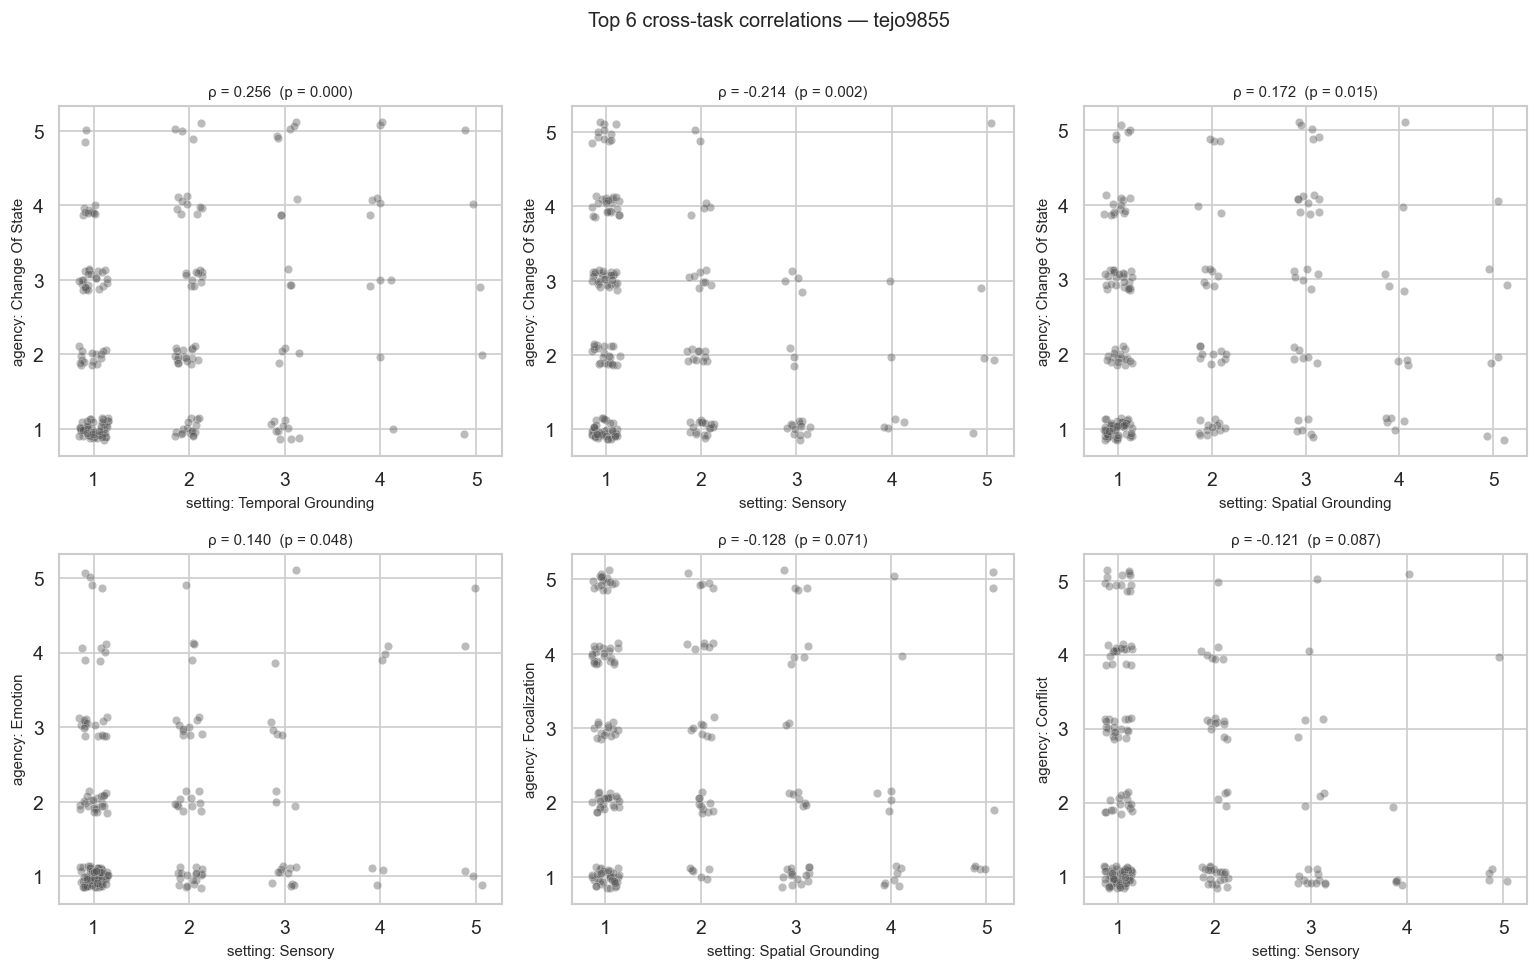

In [10]:
# Scatter plots: top 6 cross-task correlations by |rho|
top6 = cross_corr_df.head(6)
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (_, row) in zip(axes.flat, top6.iterrows()):
    sd = [k for k, v in SHORT.items() if v == row['setting']][0]
    ad = [k for k, v in SHORT.items() if v == row['agency']][0]
    ax.scatter(cross_df[sd], cross_df[ad],
               alpha=0.5, s=30, color='#555', edgecolors='white', linewidths=0.4)
    # add jitter for discrete data
    jx = cross_df[sd] + np.random.uniform(-0.15, 0.15, len(cross_df))
    jy = cross_df[ad] + np.random.uniform(-0.15, 0.15, len(cross_df))
    ax.clear()
    ax.scatter(jx, jy, alpha=0.4, s=25, color='#555', edgecolors='white', linewidths=0.3)
    ax.set_xlabel(f'setting: {row["setting"]}', fontsize=9)
    ax.set_ylabel(f'agency: {row["agency"]}', fontsize=9)
    ax.set_title(f'ρ = {row["rho"]:.3f}  (p = {row["p"]:.3f})', fontsize=9)

plt.suptitle(f'Top 6 cross-task correlations — {ANNOTATOR}', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()